# Pretrain Sequence Encoder for K562

In this tutorial, we will train a sequence encoder to predict chromatin accessibility for K562 cells. This is similar to ChromBPNet and the idea is to learn sequence variation across the whole genome.

## Overview

The goal of this tutorial is to demonstrate how to:
1. **Prepare multiome single-cell data** from K562 cells containing both RNA and ATAC-seq measurements
2. **Train a deep learning model** that learns to predict chromatin accessibility patterns from DNA sequences
3. **Use the pretrained encoder** as a foundation for downstream cell2net modeling tasks

Let's get started!

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from scipy import stats
import torch
import cell2net as cn
import mudata as md
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

md.set_options(pull_on_update=False)

## Load Multiome Data

Let's first import the multiome single-cell data for K562 cells. This dataset contains paired measurements of gene expression (RNA-seq) and chromatin accessibility (ATAC-seq) from the same cells.

In [2]:
mdata = md.read_h5mu(
    "../../../../results/37_K562_10x_multiome/05_create_mdata/mdata.h5mu"
)

Let's examine the structure of our multiome data:

In [3]:
mdata

MuData object with n_obs × n_vars = 6508 × 151699
  obs:	'total_counts_rna', 'total_counts_atac', 'total_counts_rna_log', 'total_counts_atac_log'
  2 modalities
    rna:	6508 x 15735
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'genes', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'hvg'
      obsm:	'X_pca', 'X_umap'
      layers:	'counts'
    atac:	6508 x 135964
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'peaks', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      obsm:	'X_umap'
      layers:	'counts'

## Visualize data

Let's visualize the RNA and ATAC data to understand the cellular diversity and data quality in our K562 dataset.

RNA UMAP visualization:

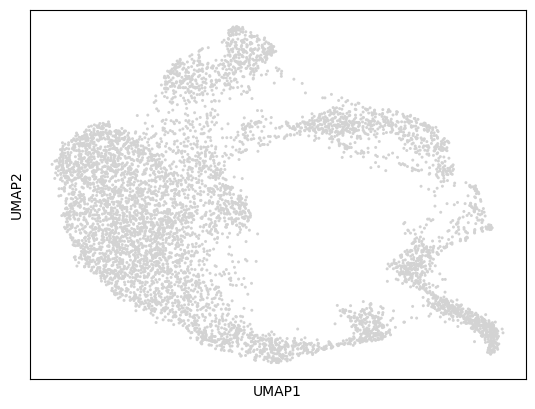

In [4]:
sc.pl.umap(mdata["rna"])

ATAC UMAP visualization:

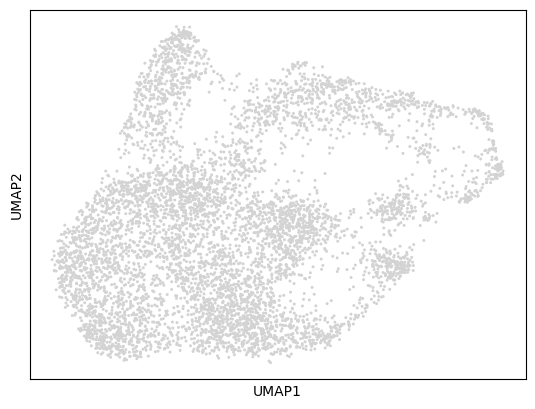

In [5]:
sc.pl.umap(mdata["atac"])

## Prepare Training Data

Now we prepare the data for sequence encoder training by:
1. **Adding peak regions** with 256bp windows around accessibility peaks
2. **Extracting DNA sequences** from the reference genome for each peak region

This creates paired sequence-accessibility data for training the neural network.

In [6]:
cn.pp.add_peaks(mdata, mod_name='atac', peak_len=256)
cn.pp.add_dna_sequence(mdata, ref_fasta='../../../../data/refdata-gex-GRCh38-2020-A/fasta/genome.fa')

Fetching sequences: 100%|██████████| 135964/135964 [00:12<00:00, 10676.39it/s]



## Calculate Accessibility Scores

Compute total accessibility for each peak by summing counts across all cells, then apply log1p transformation to normalize the distribution.

In [7]:
df_seq = mdata['atac'].uns['peaks']
df_true = mdata['atac'].layers['counts'].todense().sum(axis=0)
df_seq['acc'] = np.array(df_true).flatten()
df_seq['acc'] = np.log1p(df_seq['acc'])

Let's examine our prepared training data:

In [8]:
df_seq.head()

,chr,start,end,summit,sequence,acc
chr1-812439-812939,chr1,812561,812817,812689,GATAAACATGGAAGCAACCCACATGTCCATCAGTGGATGAATAGAT...,5.802118
chr1-817080-817580,chr1,817202,817458,817330,GACAACCTACTGAATGAGAGAAACTATTTGCAAACTATGCATCTGA...,5.961005
chr1-819720-820220,chr1,819842,820098,819970,TTTCATTCTGAGTAGCTTGATGAAGTCTCATGCCGTCCCACTCAGC...,5.552959
chr1-820480-820980,chr1,820602,820858,820730,ACACTACCTGCTTGTCCAGCAGGTCCACACTGTCTACACTACCTGC...,5.442418
chr1-821021-821521,chr1,821143,821399,821271,CAGCTGATCCGCCCTGTCTACACTACCTGCTTGTCGAGCAGATCTG...,5.361292


## Create Train/Validation Split

We split the data by chromosome to ensure no sequence similarity between training and validation sets. This approach prevents data leakage and provides a more realistic evaluation of model performance on unseen genomic regions.

In [9]:
# split data into training and validation sets by chromosome
chromosomes = df_seq['chr'].unique().tolist()
np.random.seed(42)
np.random.shuffle(chromosomes)
split_idx = int(len(chromosomes) * 0.8)
train_chromosomes = chromosomes[:split_idx]
valid_chromosomes = chromosomes[split_idx:]

df_train = df_seq[df_seq['chr'].isin(train_chromosomes)]
df_valid = df_seq[df_seq['chr'].isin(valid_chromosomes)]

Prepare final training datasets with only the essential columns (DNA sequence and accessibility score):

In [10]:
df_train = df_train[['sequence', 'acc']].reset_index(drop=True)
df_valid = df_valid[['sequence', 'acc']].reset_index(drop=True)

## Visualize Data Distribution

Let's examine the distribution of accessibility scores in our training and validation sets to ensure they are well-balanced.

Training set distribution:

<Axes: xlabel='acc', ylabel='Count'>

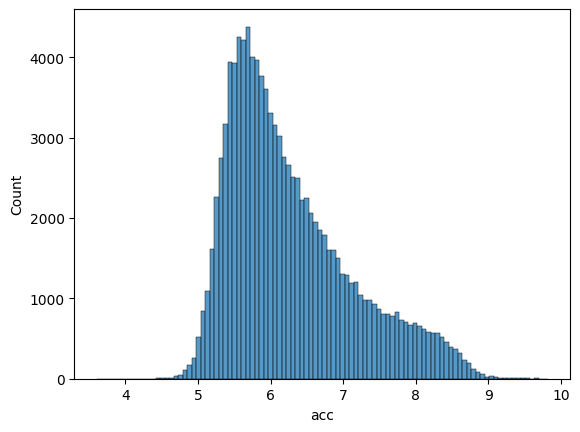

In [11]:
sns.histplot(df_train['acc'], bins=100)

Validation set distribution:

<Axes: xlabel='acc', ylabel='Count'>

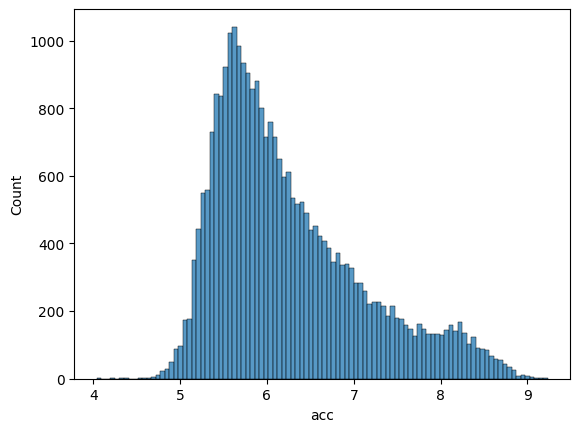

In [12]:
sns.histplot(df_valid['acc'], bins=100)

## Initialize Sequence-to-Accessibility Model

Create a Seq2Acc model with:
- **peak_len=256**: Input sequence length of 256 base pairs
- **dropout_rate=0.25**: Regularization to prevent overfitting

This model uses convolutional neural networks to learn sequence patterns that predict chromatin accessibility.

In [13]:
model = cn.pd.model.Seq2Acc(peak_len=256, dropout_rate=0.25)

## Train the Sequence Encoder

Train the model with the following parameters:
- **max_epochs=100**: Maximum training iterations
- **batch_size=512**: Number of sequences processed simultaneously
- **weight_decay=1e-04**: L2 regularization strength
- **lr=3e-04**: Learning rate for optimization

The model learns to predict accessibility from DNA sequence patterns through backpropagation.

In [14]:
model.train(df_train=df_train, df_valid=df_valid, max_epochs=100, 
            batch_size=512, weight_decay=1e-04, lr=3e-04)

2025-11-21 17:22:50 INFO     Creating dataloaders for training and validation
2025-11-21 17:23:06 INFO     Training peaks: 107414, Validation peaks: 28550
2025-11-21 17:23:06 INFO     Training peaks: 107414, Validation peaks: 28550
2025-11-21 17:23:14 INFO     Start training
2025-11-21 17:23:14 INFO     Start training
2025-11-21 17:23:22 INFO     Epoch 0:, Train: 31.2865, Valid: 13.8941, Best: 13.8941
2025-11-21 17:23:22 INFO     Epoch 0:, Train: 31.2865, Valid: 13.8941, Best: 13.8941
2025-11-21 17:23:25 INFO     Epoch 1:, Train: 5.5805, Valid: 0.7167, Best: 0.7167
2025-11-21 17:23:25 INFO     Epoch 1:, Train: 5.5805, Valid: 0.7167, Best: 0.7167
2025-11-21 17:23:29 INFO     Epoch 2:, Train: 2.2380, Valid: 0.6533, Best: 0.6533
2025-11-21 17:23:29 INFO     Epoch 2:, Train: 2.2380, Valid: 0.6533, Best: 0.6533
2025-11-21 17:23:33 INFO     Epoch 3:, Train: 1.8829, Valid: 0.5764, Best: 0.5764
2025-11-21 17:23:33 INFO     Epoch 3:, Train: 1.8829, Valid: 0.5764, Best: 0.5764
2025-11-21 17:23:3

## Save Pretrained Model

Save the trained sequence encoder weights for use in downstream Cell2Net modeling. This pretrained encoder captures fundamental sequence-to-accessibility relationships that can improve Cell2Net performance through transfer learning.

In [15]:
model.save_module('./pretrained_seq2acc.pth')

2025-11-21 17:25:55 INFO     Trained module saved to ./pretrained_seq2acc.pth


## Load Best Model for Evaluation

Reload the best model weights (based on validation performance) for final evaluation and prediction visualization.

In [16]:
# load best model weights
pretrained_state_dict = torch.load('./pretrained_seq2acc.pth')
model.module.seq_encoder.load_state_dict(pretrained_state_dict)

<All keys matched successfully>

## Generate Predictions

Use the trained model to predict accessibility scores for both training and validation datasets.

In [17]:
df_train['pred_acc'] = model.predict(df_train)
df_valid['pred_acc'] = model.predict(df_valid)

Predicting: 100%|██████████| 840/840 [00:03<00:00, 222.66it/s]

Predicting: 100%|██████████| 224/224 [00:01<00:00, 209.56it/s]


## Evaluate Model Performance

### Training Set Performance

Visualize model predictions vs. true accessibility scores on the training set. The Pearson correlation coefficient measures how well the model learned the sequence-accessibility relationships.

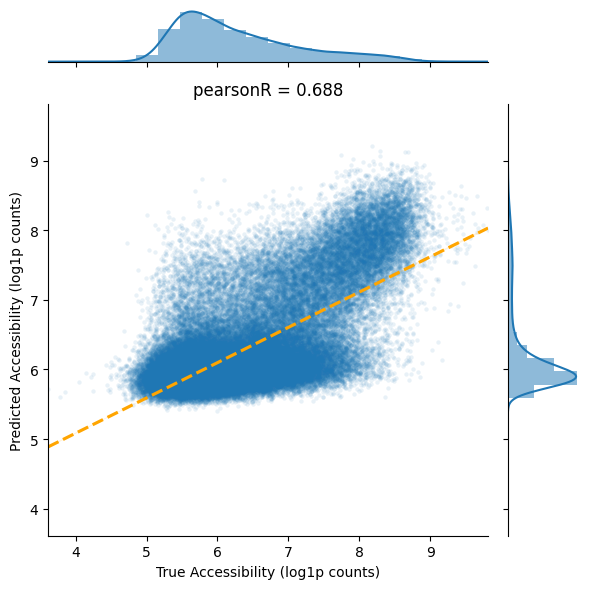

In [18]:
pearsonR, pv = stats.pearsonr(df_train['acc'], df_train['pred_acc'])

ax = sns.jointplot(
    data=df_train,
    x="acc",
    y="pred_acc",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, 
              line_kws={"color": "orange", 'linestyle':'dashed'})
_min = np.min((np.min(df_train['acc'].values), np.min(df_train['pred_acc'].values)))
_max = np.max((np.max(df_train['acc'].values), np.max(df_train['pred_acc'].values)))

# set axis-x and axis-y the same scale
plt.xlim(_min, _max)
plt.ylim(_min, _max)
plt.title('pearsonR = {:.3f}'.format(pearsonR))
plt.xlabel('True Accessibility (log1p counts)')
plt.ylabel('Predicted Accessibility (log1p counts)')
plt.tight_layout()

### Validation Set Performance

Evaluate model generalization on unseen chromosomes. This validation performance indicates how well the model can predict accessibility for completely new genomic regions, which is crucial for downstream applications.

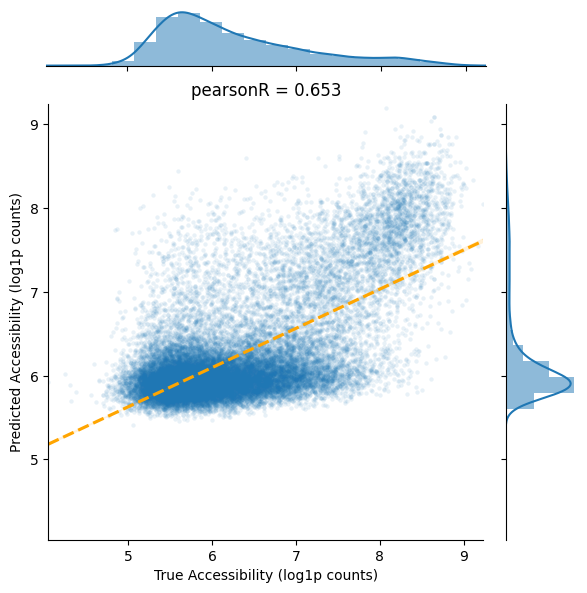

In [19]:
pearsonR, pv = stats.pearsonr(df_valid['acc'], df_valid['pred_acc'])

ax = sns.jointplot(
    data=df_valid,
    x="acc",
    y="pred_acc",
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.1, 'linewidth':0},
    marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
)
ax.plot_joint(sns.regplot, color="r", scatter=False, 
              line_kws={"color": "orange", 'linestyle':'dashed'})

_min = np.min((np.min(df_valid['acc'].values), np.min(df_valid['pred_acc'].values)))
_max = np.max((np.max(df_valid['acc'].values), np.max(df_valid['pred_acc'].values)))

# set axis-x and axis-y the same scale
plt.xlim(_min, _max)
plt.ylim(_min, _max)
plt.title('pearsonR = {:.3f}'.format(pearsonR))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('True Accessibility (log1p counts)')
plt.ylabel('Predicted Accessibility (log1p counts)')
plt.tight_layout()

## Summary and Next Steps

### ✅ What we accomplished:

1. **Loaded and preprocessed** K562 multiome single-cell data
2. **Prepared training datasets** with DNA sequences and accessibility scores
3. **Trained a sequence encoder** to predict chromatin accessibility from DNA sequence
4. **Evaluated model performance** on held-out chromosomes
5. **Saved pretrained weights** for downstream Cell2Net applications

### 🎯 Key results:
- The model successfully learned sequence-to-accessibility relationships
- Validation performance demonstrates generalization to unseen genomic regions
- Pretrained encoder is ready for transfer learning in Cell2Net models

### 💡 Biological insights:
The trained sequence encoder has learned fundamental patterns that link DNA sequence features to chromatin accessibility. This knowledge can now be transferred to Cell2Net models, potentially improving their ability to predict gene expression from regulatory sequences and cell-specific accessibility patterns.

The pretrained encoder serves as a foundation for understanding regulatory grammar and can be fine-tuned for specific cell types or experimental conditions in downstream analyses.